# Predição e Interpretabilidade por Perturbação de Tokens (Occlusion / Ablation)
___

Este notebook tem como objetivo:
1. **Carregar o modelo de Regressão Logística/Linear** previamente treinado e serializado via `joblib`.
2. **Receber um texto de entrada** arbitrário.
3. **Extrair a representação do texto**:
   - Embeddings densos com o BERTimbau (`neuralmind/bert-base-portuguese-cased`) [768 dimensões].
   - Características textuais e estilísticas (caixa alta, pontuações, caracteres especiais) [4 dimensões].
   - Totalizando as **772 features** utilizadas no treinamento do modelo do projeto (`data_bert_train.npz`).
4. **Realizar a predição inicial** (classe predita e distribuição de probabilidades).
5. **Executar a Análise de Perturbação (*Leave-One-Token-Out / Occlusion Analysis*)**:
   - Cada token do texto é removido individualmente.
   - Avalia-se a alteração na probabilidade da classe original:
     $$\Delta = P(\text{classe} \mid \text{texto original}) - P(\text{classe} \mid \text{texto sem o token } i)$$
   - Se $\Delta > 0$: a remoção do token reduziu a certeza do modelo, o que indica que o token **favorece** a classe prevista.
   - Se $\Delta < 0$: a remoção do token aumentou a certeza do modelo, indicando que o token **atua contra** a classe prevista.
   - $|\Delta|$ representa a **magnitude da importância** daquele token.
6. **Exibir e Visualizar a Importância dos Tokens**:
   - Tabela detalhada via `pandas.DataFrame`.
   - Gráfico de barras com impacto e direção das palavras.
   - Visualização de texto com destaque visual colorido (*highlighting*).


In [1]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import AutoTokenizer, AutoModel
from IPython.display import display, HTML

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 11, 'figure.autolayout': True})

# Configuração do dispositivo de processamento (GPU ou CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de execução selecionado: {device}")


c:\Users\lucas_60v3pre\Documents\Stroj---Resindecia-IA-Puc-Eldorado\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo de execução selecionado: cpu


### Configuração dos Caminhos e Parâmetros do Modelo
___

Defina abaixo o caminho do arquivo do modelo salvo via `joblib` (por padrão, `logistic_regression_model.pkl`).


In [2]:
# Nome ou caminho do arquivo do modelo salvo com joblib
MODEL_PATH = "results/logistic_regression_model.pkl"

# Modelo BERTimbau pré-treinado para extração de embeddings
BERT_MODEL_NAME = "neuralmind/bert-base-portuguese-cased"

# Mapeamento amigável das classes (ajuste conforme seu dataset, ex: {0: 'Falso/Fake', 1: 'Verdadeiro/Real'})
CLASS_NAMES = {0: "Classe 0 (Falso / Fake)", 1: "Classe 1 (Verdadeiro / Real)"}

# Carregamento do Tokenizer e Modelo BERT
print(f"Carregando tokenizer e modelo BERT: {BERT_MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model = AutoModel.from_pretrained(BERT_MODEL_NAME).to(device)
bert_model.eval()
print("BERTimbau carregado com sucesso!")

# Carregamento do modelo serializado com joblib
if os.path.exists(MODEL_PATH):
    print(f"Carregando modelo treinado de: {MODEL_PATH}")
    model = joblib.load(MODEL_PATH)
    n_feat = getattr(model, "n_features_in_", "N/A")
    print(f"Modelo carregado com sucesso! (Features esperadas pelo modelo: {n_feat})")
else:
    print(f"Atenção: O arquivo '{MODEL_PATH}' não foi encontrado no diretório atual.")
    print("Criando e ajustando um modelo LogisticRegression de demonstração (772 features) para permitir o teste imediato...")
    from sklearn.linear_model import LogisticRegression
    
    np.random.seed(42)
    sample_X = np.random.randn(20, 772)
    sample_y = np.random.choice([0, 1], size=20)
    
    model = LogisticRegression(max_iter=1000)
    model.fit(sample_X, sample_y)
    joblib.dump(model, MODEL_PATH)
    print(f"Modelo de demonstração salvo em '{MODEL_PATH}'.")


Carregando tokenizer e modelo BERT: neuralmind/bert-base-portuguese-cased...


Loading weights: 100%|██████████| 199/199 [00:00<?, ?it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTimbau carregado com sucesso!
Carregando modelo treinado de: results/logistic_regression_model.pkl
Modelo carregado com sucesso! (Features esperadas pelo modelo: 768)


### Extração de Características (Embeddings BERT + Features Textuais)
___

O modelo de classificação foi treinado com **772 features**:
- **768 features:** Embeddings densos extraídos pelo BERTimbau através do token `[CLS]`.
- **4 features textuais/estilísticas:**
  1. `caixa_alta_predominante`: proporção de maiúsculas > 50%.
  2. `multiplas_exclamacoes`: presença de exclamações repetidas (`!{2,}`).
  3. `multiplas_interrogacoes`: presença de interrogações repetidas (`?{2,}`).
  4. `possui_caracteres_especiais`: presença de caracteres especiais (`[#@$%*_+=<>|~^]`).

As funções abaixo garantem a extração e concatenação exata dessas características.


In [3]:
def chunk_text_by_tokens(text, max_tokens=128, overlap=20):
    """Divide textos longos em chunks com sobreposição para o BERT."""
    tokens = tokenizer.encode(text, add_special_tokens=False)
    if len(tokens) <= max_tokens:
        return [text]
    
    chunks = []
    stride = max_tokens - overlap
    for i in range(0, len(tokens), stride):
        chunk_tokens = tokens[i : i + max_tokens]
        chunk_text = tokenizer.decode(chunk_tokens, skip_special_tokens=True)
        chunks.append(chunk_text)
    return chunks


def extract_bert_embedding(text, max_length=512):
    """
    Gera o vetor de embedding BERT (768 dimensões) para o texto fornecido.
    Retorna uma matriz numpy com formato (1, 768).
    """
    text = text.strip()
    if not text:
        return np.zeros((1, bert_model.config.hidden_size))
        
    text_chunks = chunk_text_by_tokens(text, max_tokens=max_length - 2, overlap=20)
    chunk_vectors = []
    
    with torch.no_grad():
        for chunk in text_chunks:
            inputs = tokenizer(
                chunk,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            ).to(device)
            
            outputs = bert_model(**inputs)
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            chunk_vectors.append(cls_emb)
            
    doc_embedding = np.mean(np.vstack(chunk_vectors), axis=0, keepdims=True)
    return doc_embedding


def extract_text_features(text):
    """
    Extrai as 4 características textuais adicionais utilizadas no modelo (formato 1x4):
    1. Caixa alta predominante (> 50% das letras em maiúsculas)
    2. Mais de um ponto de exclamação seguido (!{2,})
    3. Mais de um ponto de interrogação seguido (?{2,})
    4. Presença de caracteres especiais ([#@$%*_+=<>|~^])
    """
    letras = [c for c in text if c.isalpha()]
    maiusculas = sum(c.isupper() for c in letras) if letras else 0
    caixa_alta = int(maiusculas / len(letras) > 0.5) if letras else 0
    
    mult_excl = int(bool(re.search(r"!{2,}", text)))
    mult_interr = int(bool(re.search(r"\?{2,}", text)))
    especiais = int(bool(re.search(r"[#@$%*_+=<>|~^]", text)))
    
    return np.array([[caixa_alta, mult_excl, mult_interr, especiais]], dtype=np.float32)


def get_model_features(text, clf):
    """
    Prepara a matriz de entrada X conforme o número de features esperado pelo modelo.
    Suporta tanto modelos com 772 features (BERT + 4 features) quanto com 768 (apenas BERT).
    """
    # Caso seja um pipeline sklearn que aceite texto bruto diretamente
    if hasattr(clf, "steps") and hasattr(clf.steps[0][1], "transform"):
        return [text]
        
    emb = extract_bert_embedding(text)  # shape (1, 768)
    n_expected = getattr(clf, "n_features_in_", 772)
    
    if n_expected == 772:
        extra_feats = extract_text_features(text)  # shape (1, 4)
        return np.hstack([emb, extra_feats])
    elif n_expected == 768:
        return emb
    else:
        # Tenta combinar caso bata com n_expected
        extra_feats = extract_text_features(text)
        combined = np.hstack([emb, extra_feats])
        if combined.shape[1] == n_expected:
            return combined
        return emb


### Função de Predição
___

Recebe um texto de entrada e o classificador treinado, gera a representação completa de features ($X$) e calcula:
- A classe final prevista ($0$ ou $1$).
- A distribuição de probabilidades (via `predict_proba` ou sigmoide).
- A confiança da predição na classe vencedora.


In [4]:
def predict_text(text, clf):
    """
    Executa a predição para um texto de entrada.
    Suporta modelos com 772 features (BERT + 4 features) ou 768 features (BERT puro).
    """
    X = get_model_features(text, clf)
        
    pred_class = int(clf.predict(X)[0])
    
    # Obtenção das probabilidades
    if hasattr(clf, "predict_proba"):
        probs = clf.predict_proba(X)[0]
    elif hasattr(clf, "decision_function"):
        score = clf.decision_function(X)[0]
        # Aplicação de sigmoid para converter a margem de decisão em probabilidade
        p1 = 1 / (1 + np.exp(-score))
        probs = np.array([1 - p1, p1])
    else:
        # Fallback binário
        probs = np.array([1.0 if pred_class == 0 else 0.0, 1.0 if pred_class == 1 else 0.0])
        
    pred_prob = float(probs[pred_class])
    
    return {
        "predicted_class": pred_class,
        "predicted_label": CLASS_NAMES.get(pred_class, f"Classe {pred_class}"),
        "confidence": pred_prob,
        "probabilities": probs
    }


### Texto de Entrada
___

Insira abaixo o texto que você deseja classificar e explicar. Você pode alterar a variável `input_text` para qualquer notícia ou frase que deseja testar.


In [79]:
# Texto de entrada para classificação e explicação
input_text = """
Vídeo mostra momento exato em que o código-fonte da urna é roubado. Confira agora!!!
""".strip()

print(f"Texto fornecido ({len(input_text.split())} palavras):")
print("-" * 60)
print(input_text)
print("-" * 60)


Texto fornecido (14 palavras):
------------------------------------------------------------
Vídeo mostra momento exato em que o código-fonte da urna é roubado. Confira agora!!!
------------------------------------------------------------


### Predição do Texto Original
___

Executamos a classificação do texto completo original para obter a classe base e as probabilidades.


In [80]:
res_original = predict_text(input_text, model)

print("=== RESULTADO DA CLASSIFICAÇÃO ===")
print(f"Classe Predita: {res_original['predicted_label']} (valor: {res_original['predicted_class']})")
print(f"Confiança:      {res_original['confidence']:.2%}")
print("Distribuição de Probabilidades:")
for idx, p in enumerate(res_original['probabilities']):
    label = CLASS_NAMES.get(idx, f"Classe {idx}")
    print(f"  • {label}: {p:.4f} ({p*100:.2f}%)")


=== RESULTADO DA CLASSIFICAÇÃO ===
Classe Predita: Classe 0 (Falso / Fake) (valor: 0)
Confiança:      99.58%
Distribuição de Probabilidades:
  • Classe 0 (Falso / Fake): 0.9958 (99.58%)
  • Classe 1 (Verdadeiro / Real): 0.0042 (0.42%)


### Análise de Perturbação (*Leave-One-Token-Out*)
___

**Metodologia:**
1. O texto é decomposto em tokens/palavras preservando espaçamento e pontuações.
2. Para cada token $i$:
   - Uma versão do texto é reconstruída **sem** o token $i$.
   - O classificador recalcula a probabilidade da classe original predita:
     $$\Delta = P_{\text{original}} - P_{\text{sem token } i}$$
   - **Interpretação:**
     - $\Delta > 0$: O token **sustenta** a classe original (ao ser removido, a confiança do modelo caiu).
     - $\Delta < 0$: O token **enfraquece** a classe original (ao ser removido, a confiança do modelo subiu).
     - $|\Delta|$: **Importância absoluta** da palavra para a decisão tomada.


In [81]:
def tokenize_text_words(text):
    """
    Divide o texto preservando palavras e pontuações para reconstrução precisa.
    Retorna uma lista de tuplas (token, inicio_char, fim_char).
    """
    matches = list(re.finditer(r'\w+|[^\w\s]', text, re.UNICODE))
    tokens_info = [(m.group(), m.start(), m.end()) for m in matches]
    return tokens_info


def analyze_token_perturbation(text, clf, mode="mask", verbose=True):
    """
    Executa a análise de perturbação token a token.
    
    Parâmetro 'mode':
      - 'mask' (Recomendado para BERT): substitui o token por [MASK], preservando
        a geometria sintática e posicional do transformer sem gerar ruído estrutural.
      - 'delete': remove fisicamente o token do texto.
    """
    base_res = predict_text(text, clf)
    target_class = base_res['predicted_class']
    p_orig = base_res['confidence']
    
    tokens_info = tokenize_text_words(text)
    num_tokens = len(tokens_info)
    
    if verbose:
        print(f"Iniciando análise de perturbação para {num_tokens} tokens (Modo: '{mode}')...")
        print(f"Classe alvo da análise: {base_res['predicted_label']} (Prob inicial: {p_orig:.4f})\n")
        
    records = []
    
    for i, (token, start, end) in enumerate(tokens_info):
        # Gera a versão perturbada conforme o modo escolhido
        if mode == "mask":
            # Substitui o token pontualmente pelo token nativo [MASK] do BERT
            perturbed_text = (text[:start] + "[MASK]" + text[end:]).strip()
        else:
            # Remove o token
            perturbed_text = (text[:start] + text[end:]).strip()
            
        perturbed_text = re.sub(r'\s+', ' ', perturbed_text)
        
        # Realiza a predição para a frase perturbada
        res_pert = predict_text(perturbed_text, clf)
        p_pert = float(res_pert['probabilities'][target_class])
        new_class = res_pert['predicted_class']
        
        # Variação na probabilidade da classe original
        delta = p_orig - p_pert
        abs_impact = abs(delta)
        
        if delta > 1e-5:
            direcao = "A favor da classe"
        elif delta < -1e-5:
            direcao = "Contra a classe"
        else:
            direcao = "Neutro"
            
        records.append({
            "Posicao": i + 1,
            "Token": token,
            "Prob_Original": round(p_orig, 4),
            "Prob_Sem_Token": round(p_pert, 4),
            "Impacto_Delta": round(delta, 4),
            "Importancia_Absoluta": round(abs_impact, 4),
            "Direcao": direcao,
            "Classe_Sem_Token": res_pert['predicted_label'],
            "Mudou_Classe": (new_class != target_class),
            "Texto_Perturbado": perturbed_text
        })
        
    df = pd.DataFrame(records)
    return df, base_res


In [82]:
# Executa a análise de perturbação no texto de entrada
# Experimente mode="mask" (recomendado para BERT) ou mode="delete"
df_perturbation, base_prediction = analyze_token_perturbation(input_text, model, mode="mask", verbose=True)

# Exibe os tokens ordenados pela maior importância absoluta
df_sorted = df_perturbation.sort_values(by="Importancia_Absoluta", ascending=False).reset_index(drop=True)

print("Top 10 Tokens Mais Importantes para a Classificação:")
display(df_sorted[["Posicao", "Token", "Impacto_Delta", "Importancia_Absoluta", "Direcao", "Prob_Sem_Token", "Mudou_Classe"]].head(10))


Iniciando análise de perturbação para 20 tokens (Modo: 'mask')...
Classe alvo da análise: Classe 0 (Falso / Fake) (Prob inicial: 0.9958)

Top 10 Tokens Mais Importantes para a Classificação:


,Posicao,Token,Impacto_Delta,Importancia_Absoluta,Direcao,Prob_Sem_Token,Mudou_Classe
0,12,urna,0.0298,0.0298,A favor da classe,0.9660,False
1,19,!,0.0113,0.0113,A favor da classe,0.9845,False
2,15,.,0.0099,0.0099,A favor da classe,0.9859,False
3,1,Vídeo,0.0063,0.0063,A favor da classe,0.9895,False
4,14,roubado,0.0057,0.0057,A favor da classe,0.9900,False
5,16,Confira,0.0045,0.0045,A favor da classe,0.9913,False
6,17,agora,0.0033,0.0033,A favor da classe,0.9925,False
7,18,!,0.0032,0.0032,A favor da classe,0.9926,False
8,3,momento,0.0029,0.0029,A favor da classe,0.9929,False
9,20,!,0.0028,0.0028,A favor da classe,0.9929,False


### Tabela Completa de Importância por Ordem no Texto
___

Exibição sequencial da influência de cada token na frase.


In [83]:
display(df_perturbation[["Posicao", "Token", "Impacto_Delta", "Importancia_Absoluta", "Direcao", "Prob_Sem_Token", "Mudou_Classe"]])


,Posicao,Token,Impacto_Delta,Importancia_Absoluta,Direcao,Prob_Sem_Token,Mudou_Classe
0,1,Vídeo,0.0063,0.0063,A favor da classe,0.9895,False
1,2,mostra,-0.0008,0.0008,Contra a classe,0.9966,False
2,3,momento,0.0029,0.0029,A favor da classe,0.9929,False
3,4,exato,-0.0006,0.0006,Contra a classe,0.9963,False
4,5,em,0.0008,0.0008,A favor da classe,0.9950,False
5,6,que,0.0004,0.0004,A favor da classe,0.9954,False
6,7,o,-0.0004,0.0004,Contra a classe,0.9961,False
7,8,código,-0.0020,0.0020,Contra a classe,0.9978,False
8,9,-,-0.0011,0.0011,Contra a classe,0.9968,False
9,10,fonte,-0.0011,0.0011,Contra a classe,0.9969,False


### Visualização Gráfica da Importância dos Tokens
___

Gráfico horizontal evidenciando o impacto de cada token:
- **Verde**: O token apoia a predição da classe (ao removê-lo, a probabilidade cai).
- **Vermelho**: O token contraria a classe (ao removê-lo, a probabilidade sobe).
- O comprimento da barra indica a magnitude do impacto ($|\Delta|$).


<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\D'
C:\Users\lucas_60v3pre\AppData\Local\Temp\ipykernel_17328\437948086.py:11: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("Impacto na Probabilidade da Classe ($\Delta = P_{orig} - P_{sem\_token}$)", fontsize=12)


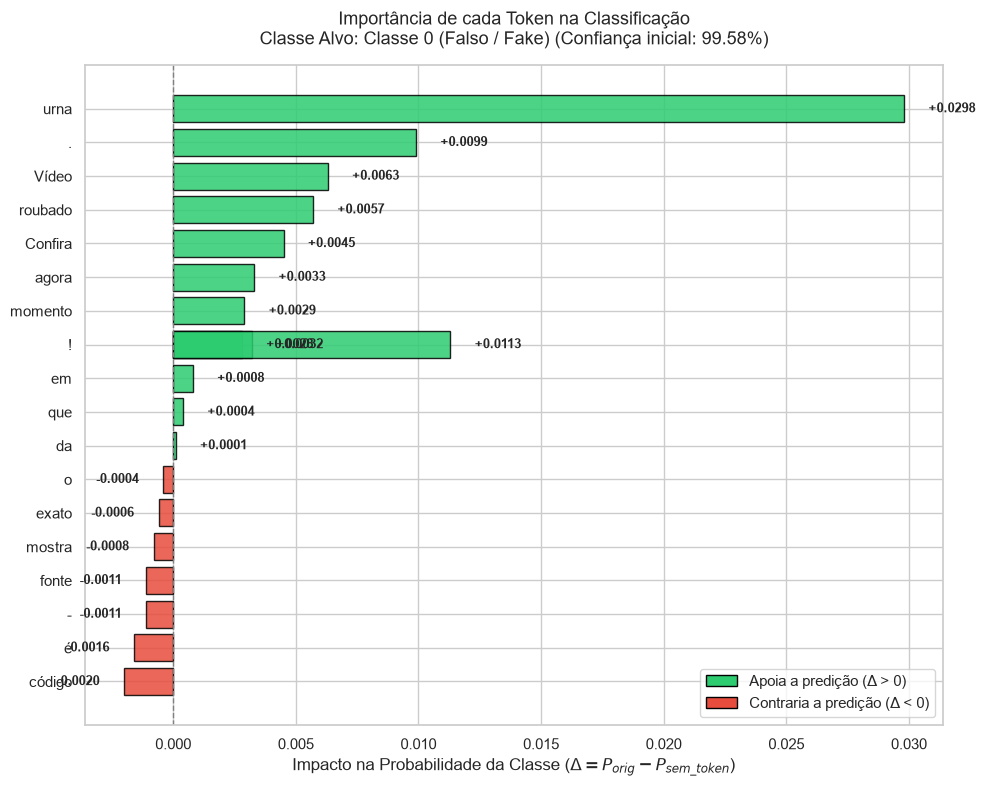

In [84]:
plt.figure(figsize=(10, max(5, len(df_perturbation) * 0.4)))

# Ordena por delta com sinal para visualização intuitiva
df_plot = df_perturbation.sort_values(by="Impacto_Delta", ascending=True)

colors = ["#2ecc71" if d > 0 else "#e74c3c" if d < 0 else "#95a5a6" for d in df_plot["Impacto_Delta"]]

bars = plt.barh(df_plot["Token"], df_plot["Impacto_Delta"], color=colors, edgecolor="black", alpha=0.85)

plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Impacto na Probabilidade da Classe ($\Delta = P_{orig} - P_{sem\_token}$)", fontsize=12)
plt.title(f"Importância de cada Token na Classificação\nClasse Alvo: {base_prediction['predicted_label']} (Confiança inicial: {base_prediction['confidence']:.2%})", fontsize=13, pad=15)

# Anotações dos valores nas barras
for bar in bars:
    w = bar.get_width()
    offset = 0.001 if w >= 0 else -0.001
    ha = 'left' if w >= 0 else 'right'
    plt.text(w + offset, bar.get_y() + bar.get_height() / 2, f"{w:+.4f}",
             va='center', ha=ha, fontsize=9, fontweight='semibold')

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", edgecolor="black", label="Apoia a predição (Δ > 0)"),
    Patch(facecolor="#e74c3c", edgecolor="black", label="Contraria a predição (Δ < 0)")
]
plt.legend(handles=legend_elements, loc="lower right", frameon=True)

plt.tight_layout()
plt.show()


### Visualização com Texto Destacado (*Interactive Token Highlighting*)
___

Visualização interativa inspirada em ferramentas como LIME e SHAP: o texto de entrada é renderizado com marcações coloridas proporcionais à importância de cada palavra.
- **Verde**: palavras que puxam para a classe predita.
- **Vermelho**: palavras que empurram em direção contrária.
- Ao passar o cursor (*hover*), um balão exibe o impacto exato e a probabilidade sem aquela palavra.


In [85]:
def render_html_token_highlights(df, base_res):
    """
    Renderiza o texto formatado em HTML com destaques proporcionais à importância de cada token.
    """
    max_impact = df["Importancia_Absoluta"].max()
    if max_impact == 0:
        max_impact = 1.0
        
    html_spans = []
    
    for _, row in df.iterrows():
        token = row["Token"]
        delta = row["Impacto_Delta"]
        abs_imp = row["Importancia_Absoluta"]
        
        # Intensidade da cor normalizada (0.12 a 0.85 de opacidade)
        alpha = min(0.85, max(0.12, (abs_imp / max_impact) * 0.85))
        
        if delta > 0.0001:
            bg_color = f"rgba(46, 204, 113, {alpha:.2f})"   # Verde
            border_color = "rgba(39, 174, 96, 0.6)"
        elif delta < -0.0001:
            bg_color = f"rgba(231, 76, 60, {alpha:.2f})"     # Vermelho
            border_color = "rgba(192, 57, 43, 0.6)"
        else:
            bg_color = "rgba(220, 220, 220, 0.3)"            # Neutro
            border_color = "transparent"
            
        tooltip = f"Token: '{token}' | Δ: {delta:+.4f} | Prob sem token: {row['Prob_Sem_Token']:.4f}"
        
        span = (
            f'<span style="background-color: {bg_color}; border: 1px solid {border_color}; '
            f'border-radius: 4px; padding: 2px 5px; margin: 2px; display: inline-block; '
            f'font-family: inherit; font-size: 1.05em;" title="{tooltip}">{token}</span>'
        )
        html_spans.append(span)
        
    legend_html = """
    <div style="margin-top: 15px; font-size: 0.9em; color: #555;">
        <span style="background-color: rgba(46, 204, 113, 0.5); padding: 2px 8px; border-radius: 3px; margin-right: 10px;">
            ■ Apoia a classe predita
        </span>
        <span style="background-color: rgba(231, 76, 60, 0.5); padding: 2px 8px; border-radius: 3px; margin-right: 10px;">
            ■ Contraria a classe predita
        </span>
    </div>
    """
    
    container_html = f"""
    <div style="border: 1px solid #ddd; border-radius: 8px; padding: 18px; background: #fafafa; line-height: 2.2;">
        <div style="margin-bottom: 12px; font-weight: bold; font-size: 1.1em;">
            Texto Explicado (Classe Predita: <span style="color: #2980b9;">{base_res['predicted_label']}</span> - Confiança: {base_res['confidence']:.2%}):
        </div>
        <div>
            {' '.join(html_spans)}
        </div>
        {legend_html}
    </div>
    """
    
    return HTML(container_html)

display(render_html_token_highlights(df_perturbation, base_prediction))


### Função Rápida para Qualquer Novo Texto
___

Utilize a função `predict_and_explain(text)` para analisar qualquer novo texto com uma única chamada.


In [86]:
def predict_and_explain(text, clf=model, plot=True):
    """
    Função utilitária completa:
    1. Prediz a classe do texto.
    2. Realiza a análise de perturbação por token.
    3. Exibe tabela, gráfico e texto interativo.
    """
    print("=" * 70)
    print(f"ANÁLISE DE TEXTO: {text}")
    print("=" * 70)
    
    df_res, base_res = analyze_token_perturbation(text, clf, verbose=False)
    
    print(f"Predição: {base_res['predicted_label']} | Confiança: {base_res['confidence']:.2%}")
    print("-" * 70)
    
    # Exibe top tokens
    df_top = df_res.sort_values(by="Importancia_Absoluta", ascending=False).reset_index(drop=True)
    print("Top 5 tokens com maior impacto:")
    display(df_top[["Token", "Impacto_Delta", "Importancia_Absoluta", "Direcao"]].head(5))
    
    if plot:
        # Gráfico
        plt.figure(figsize=(9, max(4, len(df_res) * 0.35)))
        df_p = df_res.sort_values(by="Impacto_Delta", ascending=True)
        cols = ["#2ecc71" if d > 0 else "#e74c3c" if d < 0 else "#95a5a6" for d in df_p["Impacto_Delta"]]
        plt.barh(df_p["Token"], df_p["Impacto_Delta"], color=cols, edgecolor="black", alpha=0.85)
        plt.axvline(0, color="gray", linestyle="--")
        plt.title(f"Impacto por Token - Predição: {base_res['predicted_label']} ({base_res['confidence']:.1%})")
        plt.xlabel("Impacto na Probabilidade ($\Delta$)")
        plt.tight_layout()
        plt.show()
        
    display(render_html_token_highlights(df_res, base_res))
    return df_res

# Exemplo de uso adicional:
# df_resultado = predict_and_explain("Vacina desenvolvida no Brasil apresenta eficácia comprovada em testes clínicos.")


<>:30: SyntaxWarning: invalid escape sequence '\D'
<>:30: SyntaxWarning: invalid escape sequence '\D'
C:\Users\lucas_60v3pre\AppData\Local\Temp\ipykernel_17328\3580401220.py:30: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("Impacto na Probabilidade ($\Delta$)")
